## Exploración y análisis de datos

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np


Cargamos los datos limpios

In [4]:
dff_final = pd.read_csv("dff_final.csv")
dff_final.head()

,nit_entidad,nombre_entidad,modalidad_de_contratacion,valor_del_contrato,anio,modalidad_agrupada
0,900478966,UNGRD,Contratación directa,28676000.0,2018,Contratación directa
1,900478966,UNGRD,Contratación directa,38400000.0,2024,Contratación directa
2,900478966,UNGRD,Contratación directa,63390438.0,2023,Contratación directa
3,900478966,UNGRD,Contratación directa,20081760.0,2019,Contratación directa
4,900478966,UNGRD,Contratación directa,79000000.0,2026,Contratación directa


## Exploración inicial

In [159]:
dff_final.info()


<class 'pandas.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   nit_entidad                752 non-null    int64  
 1   nombre_entidad             752 non-null    str    
 2   modalidad_de_contratacion  752 non-null    str    
 3   valor_del_contrato         752 non-null    float64
 4   anio                       752 non-null    int64  
 5   modalidad_agrupada         752 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 35.4 KB


In [160]:
dff_final.isnull().sum()


nit_entidad                  0
nombre_entidad               0
modalidad_de_contratacion    0
valor_del_contrato           0
anio                         0
modalidad_agrupada           0
dtype: int64

## Análisis univariado

### Estadísticas descriptivas del valor del contrato

In [161]:
round(dff_final['valor_del_contrato'].describe(), 0)

count    7.520000e+02
mean     3.253317e+08
std      1.625456e+09
min      1.302800e+04
25%      1.975000e+07
50%      3.874642e+07
75%      7.900000e+07
max      1.896879e+10
Name: valor_del_contrato, dtype: float64

In [162]:
print("Asimetría (skewness):", dff_final['valor_del_contrato'].skew())
print("Curtosis:", dff_final['valor_del_contrato'].kurtosis())

Asimetría (skewness): 8.69750405672671
Curtosis: 86.10140038957559


In [163]:
print(dff_final['valor_del_contrato'].max())
print(dff_final['valor_del_contrato'].sort_values(ascending=False).head(10))

18968786074.06
100    1.896879e+10
131    1.840121e+10
392    1.836845e+10
208    1.794118e+10
268    1.114700e+10
696    9.457383e+09
224    8.044745e+09
77     6.495000e+09
58     6.175328e+09
711    6.175328e+09
Name: valor_del_contrato, dtype: float64


In [164]:
dff_final['modalidad_de_contratacion'].value_counts()

modalidad_de_contratacion
Contratación directa                           536
Mínima cuantía                                  86
Selección Abreviada de Menor Cuantía            35
Contratación Directa (con ofertas)              31
Selección abreviada subasta inversa             27
Licitación pública                              27
Concurso de méritos abierto                      6
Contratación régimen especial (con ofertas)      3
Licitación pública Obra Publica                  1
Name: count, dtype: int64

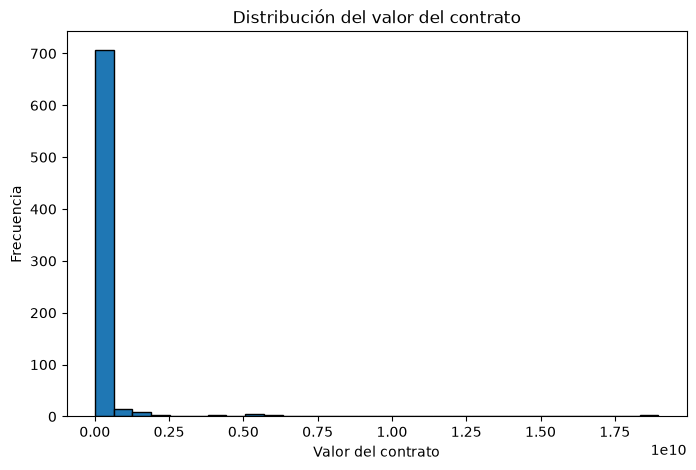

In [166]:
#Histograma (escala normal)
plt.figure(figsize=(8,5))
plt.hist(dff_final['valor_del_contrato'], bins=30, edgecolor='black')
plt.title("Distribución del valor del contrato")
plt.xlabel("Valor del contrato")
plt.ylabel("Frecuencia")
plt.show()

In [252]:
# Versión logarítmica,log_valor_contrato

dff_final['log_valor_contrato'] = np.log(dff_final['valor_del_contrato'])

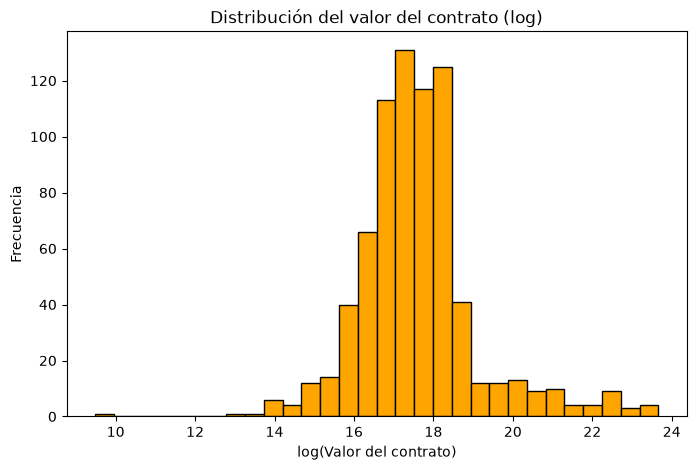

In [168]:
#Histograma (escala logarítmica), log_valor_contrato
plt.figure(figsize=(8,5))
plt.hist(dff_final['log_valor_contrato'], bins=30, edgecolor='black', color='orange')
plt.title("Distribución del valor del contrato (log)")
plt.xlabel("log(Valor del contrato)")
plt.ylabel("Frecuencia")
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_6456\2324277476.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dff_final['valor_del_contrato'], vert=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x1bd06b5e120>,
 'caps': [<matplotlib.lines.Line2D at 0x1bd06b5e3c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bd06b29010>],
 'medians': [<matplotlib.lines.Line2D at 0x1bd06b5de80>],
 'fliers': [<matplotlib.lines.Line2D at 0x1bd06b5dfd0>],
 'means': []}

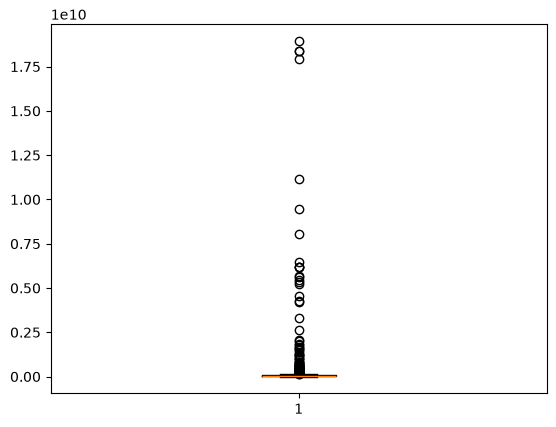

In [170]:
#Boxplot (detección de outliers)
plt.boxplot(dff_final['valor_del_contrato'], vert=True)

C:\Users\maria\AppData\Local\Temp\ipykernel_6456\2760212211.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dff_final['valor_del_contrato'], vert=True)


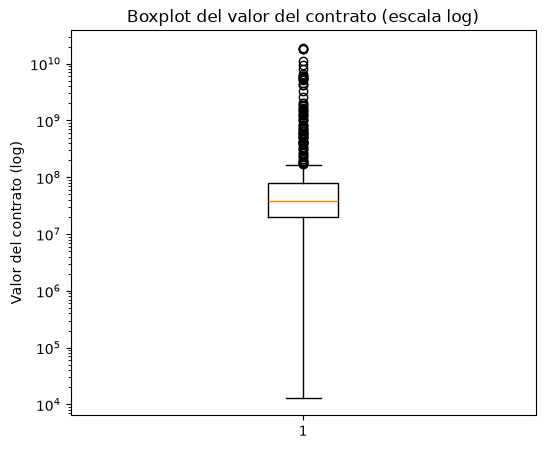

In [173]:
plt.figure(figsize=(6,5))
plt.boxplot(dff_final['valor_del_contrato'], vert=True)
plt.yscale('log')
plt.title("Boxplot del valor del contrato (escala log)")
plt.ylabel("Valor del contrato (log)")
plt.show()

### Estadísticas descriptivas modalidad de contratació

In [175]:
dff_final.groupby('modalidad_agrupada')['valor_del_contrato'].describe()

,count,mean,std,min,25%,50%,75%,max
modalidad_agrupada,,,,,,,,
Contratación Directa (con ofertas),31.0,1.918490e+08,8.106141e+08,494000.00,1.233800e+07,2.360590e+07,6.809747e+07,4.542793e+09
Contratación directa,536.0,4.976638e+07,5.029836e+07,1430198.10,2.106667e+07,3.840000e+07,6.943200e+07,5.998410e+08
Licitación pública,27.0,5.706434e+09,6.149364e+09,1507440.00,1.140519e+09,4.232481e+09,6.335164e+09,1.896879e+10
Mínima cuantía,86.0,1.496795e+07,1.294107e+07,13028.00,6.566775e+06,1.053448e+07,1.980675e+07,7.500000e+07
Otras,10.0,2.134974e+09,2.630313e+09,19992000.00,2.483607e+08,1.603593e+09,2.033391e+09,8.044745e+09
Selección Abreviada de Menor Cuantía,35.0,3.271463e+08,3.341113e+08,48691230.00,1.160236e+08,2.083957e+08,4.476308e+08,1.779122e+09
Selección abreviada subasta inversa,27.0,8.839460e+08,1.261353e+09,58596269.35,1.267803e+08,5.100000e+08,8.750000e+08,5.247551e+09


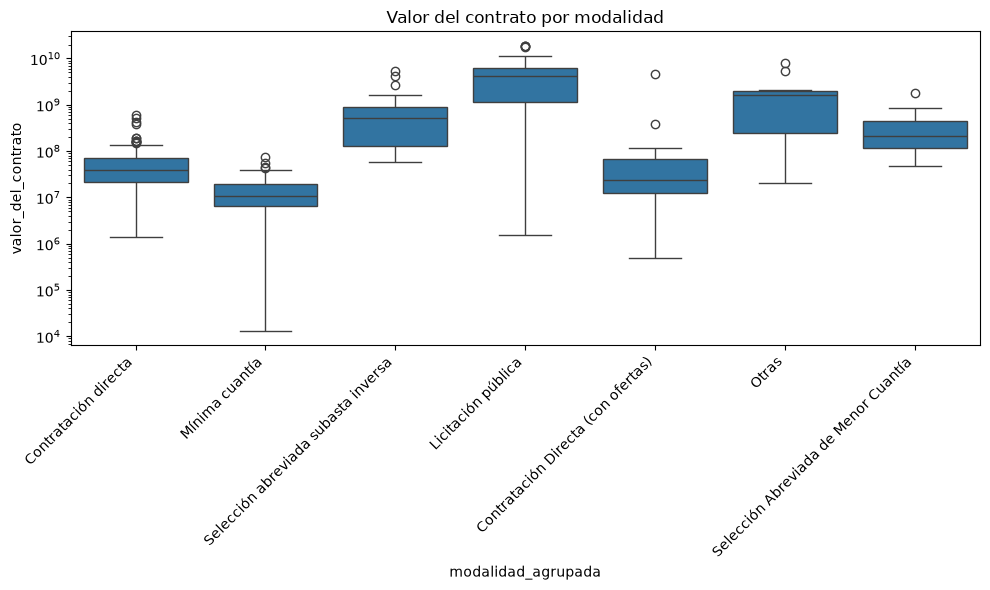

In [177]:
# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=dff_final, x='modalidad_agrupada', y='valor_del_contrato')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title("Valor del contrato por modalidad")
plt.tight_layout()
plt.show()

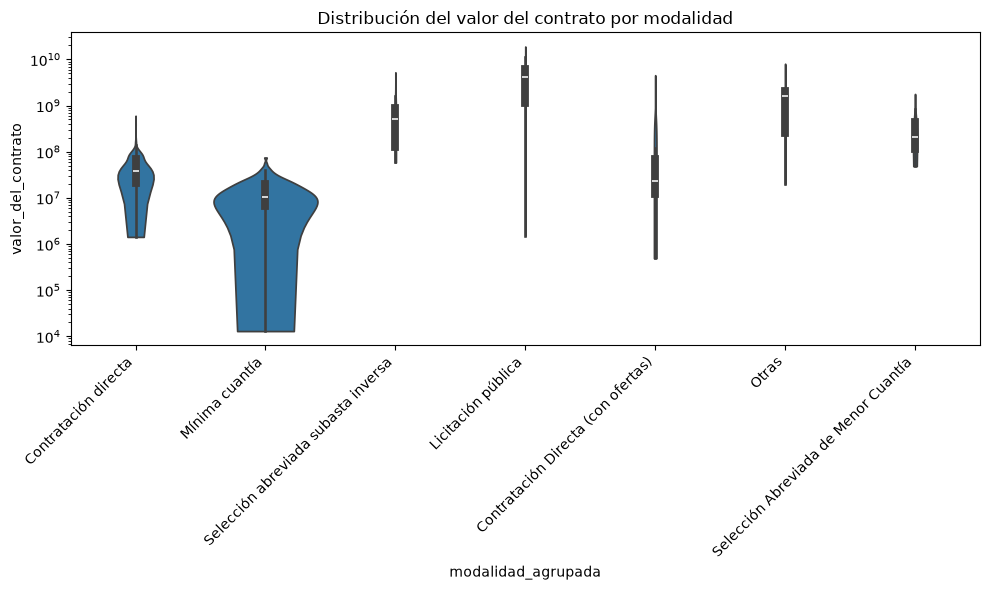

In [178]:
# Violín
plt.figure(figsize=(10,6))
sns.violinplot(data=dff_final, x='modalidad_agrupada', y='valor_del_contrato', cut=0)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title("Distribución del valor del contrato por modalidad")
plt.tight_layout()
plt.show()

In [180]:
print(dff_final['modalidad_agrupada'].value_counts())

modalidad_agrupada
Contratación directa                    536
Mínima cuantía                           86
Selección Abreviada de Menor Cuantía     35
Contratación Directa (con ofertas)       31
Selección abreviada subasta inversa      27
Licitación pública                       27
Otras                                    10
Name: count, dtype: int64


Calculamos el valor promedio y la mediana del contrato por año

In [63]:
dff_final.groupby('anio')['valor_del_contrato'].agg(['count', 'mean', 'median'])


,count,mean,median
anio,,,
2017,1,1.457560e+07,1.457560e+07
2018,89,2.514257e+07,2.079010e+07
2019,49,6.143311e+07,2.220806e+07
2020,59,4.278500e+08,2.249027e+07
2021,108,5.463622e+13,3.891469e+07
2022,99,1.900746e+08,5.615689e+07
2023,125,1.253118e+08,2.518600e+07
2024,68,1.497137e+08,3.840000e+07
2025,75,4.217142e+08,7.900000e+07


## Valor de contrato vs año

anio
2017    14575600.00
2018    20790100.00
2019    23968909.50
2020    22490267.00
2021    38848166.66
2022    56956310.70
2023    25186000.00
2024    38400000.00
2025    79000000.00
2026    86900000.00
Name: valor_del_contrato, dtype: float64


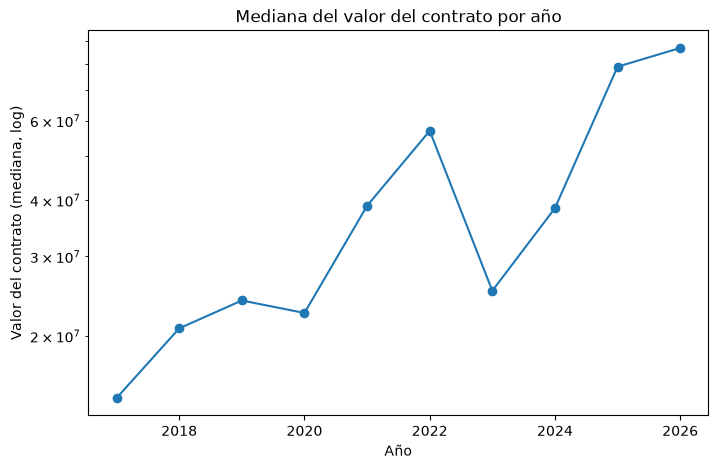

In [200]:
mediana_anual = dff_final.groupby('anio')['valor_del_contrato'].median()
print(mediana_anual)

plt.figure(figsize=(8,5))
plt.plot(mediana_anual.index, mediana_anual.values, marker='o')
plt.yscale('log')
plt.title("Mediana del valor del contrato por año")
plt.xlabel("Año")
plt.ylabel("Valor del contrato (mediana, log)")
plt.show()

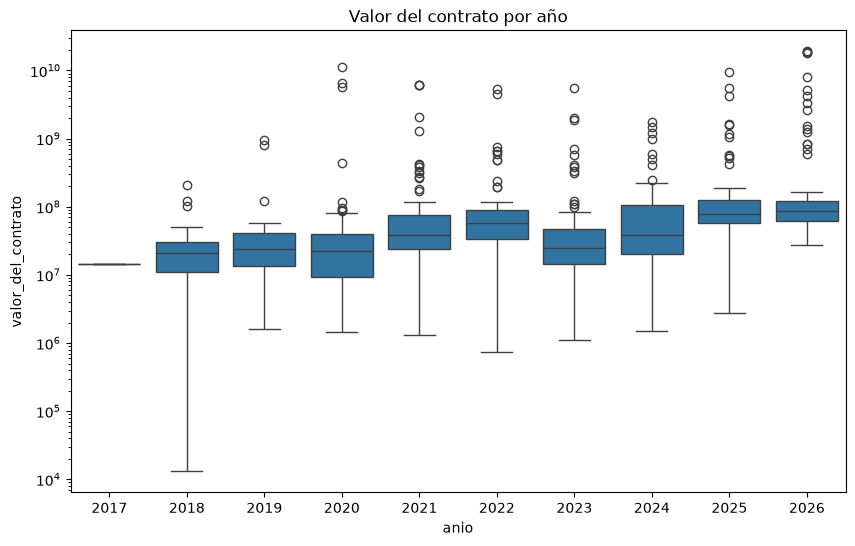

In [ ]:
#Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=dff_final, x='anio', y='valor_del_contrato')
plt.yscale('log')
plt.title("Valor del contrato por año")
plt.show()

In [ ]:
#Matriz de correlación
corr_matrix = dff_final[['anio', 'valor_del_contrato']].corr()
print(corr_matrix)

                        anio  valor_del_contrato
anio                1.000000            0.146459
valor_del_contrato  0.146459            1.000000


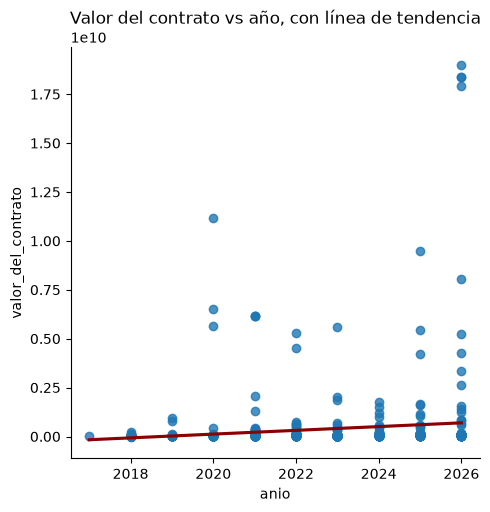

In [ ]:
# Dispersión con línea de regresión
sns.lmplot(x='anio', y='valor_del_contrato', data=dff_final, line_kws={'color': 'darkred'}, ci=False)
plt.title("Valor del contrato vs año, con línea de tendencia")
plt.show()

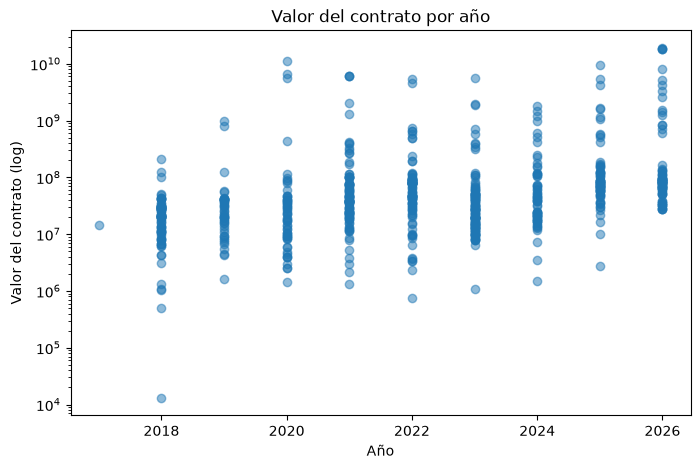

In [ ]:
#Diagrama de dispersión
plt.figure(figsize=(8,5))
plt.scatter(dff_final['anio'], dff_final['valor_del_contrato'], alpha=0.5)
plt.yscale('log')
plt.title("Valor del contrato por año")
plt.xlabel("Año")
plt.ylabel("Valor del contrato (log)")
plt.show()

## Valor de contrato vs modalidad de contratación

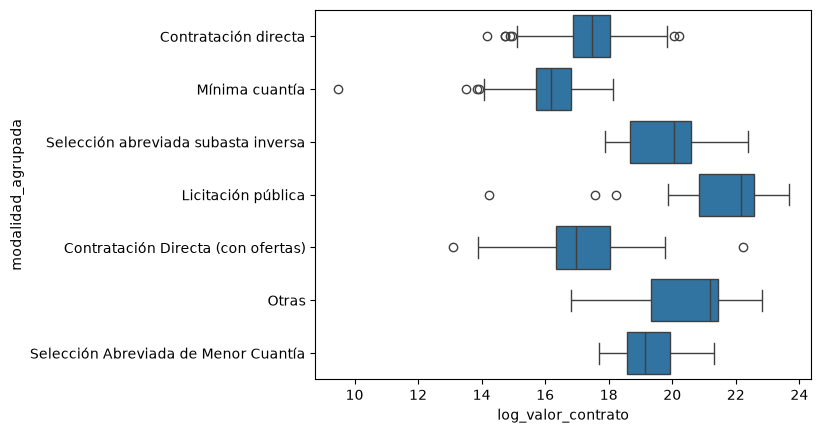

In [205]:
sns.boxplot(data=dff_final, x='log_valor_contrato', y='modalidad_agrupada')
plt.show()


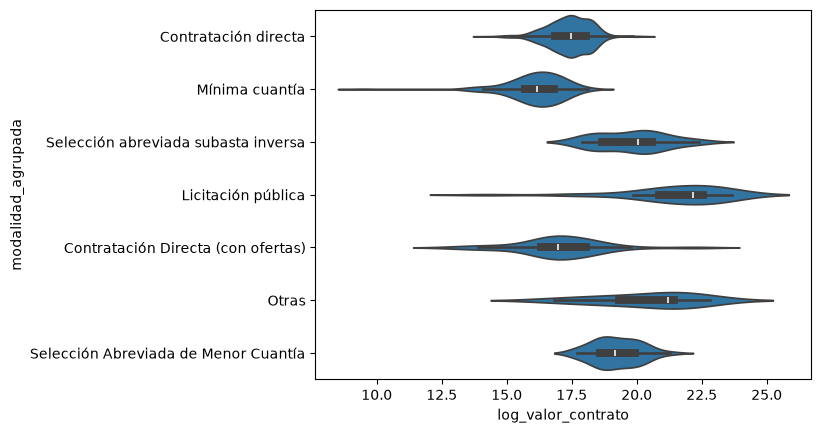

In [207]:
sns.violinplot(data=dff_final, x='log_valor_contrato', y='modalidad_agrupada')
plt.show()


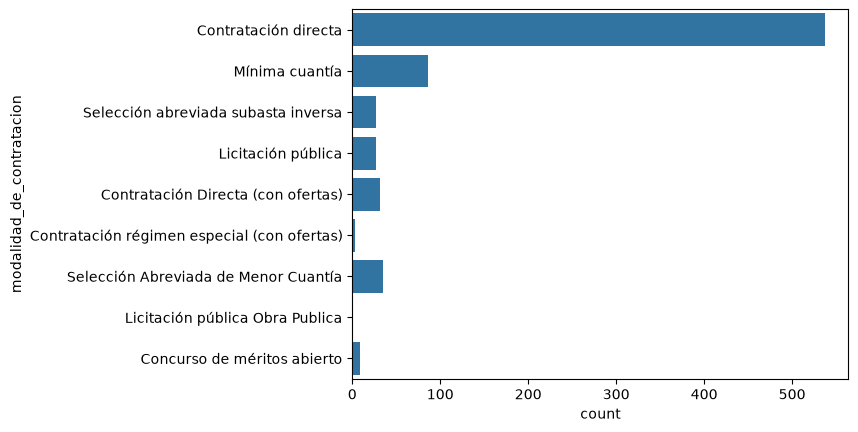

In [ ]:
sns.countplot(data=dff_final, y='modalidad_agrupada')
plt.show()


## Valor de contrato vs modalidad de contratación y año

mediana del valor del contrato por modalidad y año

In [208]:
tabla = dff_final.pivot_table(index='modalidad_agrupada', columns='anio',
                               values='valor_del_contrato', aggfunc='median')
round(tabla, 0)


anio,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
modalidad_agrupada,,,,,,,,,,
Contratación Directa (con ofertas),NaN,11000000.0,28970370.0,2.360590e+07,2.000000e+07,5.496499e+07,2.639522e+07,6.509445e+07,9.070348e+07,NaN
Contratación directa,NaN,21464200.0,34255274.0,2.803657e+07,3.882469e+07,5.775574e+07,2.220240e+07,2.438800e+07,7.200000e+07,7.900000e+07
Licitación pública,NaN,NaN,881950308.0,6.495000e+09,6.175328e+09,5.315072e+09,9.630471e+08,1.225330e+09,4.232481e+09,1.815482e+10
Mínima cuantía,14575600.0,7376736.0,8865630.0,9.658300e+06,9.981720e+06,1.077988e+07,1.129006e+07,1.980900e+07,2.132774e+07,3.568390e+07
Otras,NaN,NaN,19992000.0,NaN,1.157920e+09,1.592785e+08,1.996044e+09,NaN,3.553150e+09,4.796505e+09
Selección Abreviada de Menor Cuantía,NaN,122213000.0,121960080.0,1.064436e+08,1.841932e+08,4.841929e+08,3.236411e+08,2.354748e+08,1.686042e+08,8.341710e+08
Selección abreviada subasta inversa,NaN,NaN,58596269.0,4.373572e+08,1.914740e+08,6.555155e+08,4.098349e+08,5.100000e+08,1.700000e+08,2.625671e+09


mapa de calor

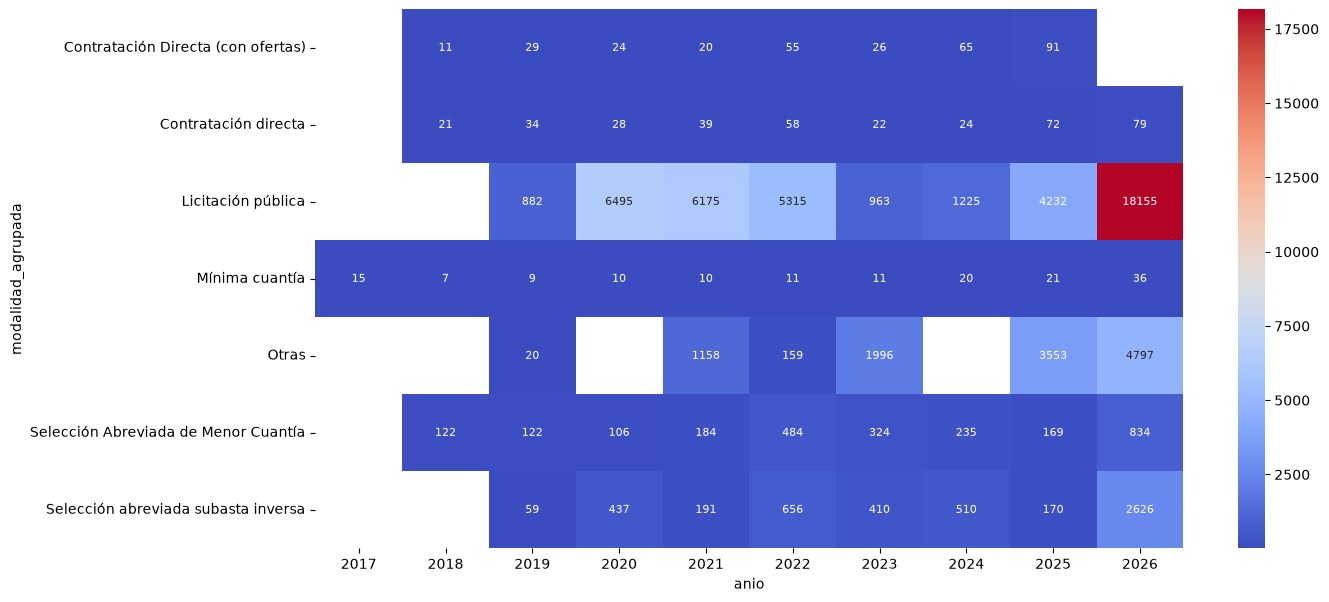

In [ ]:
tabla_millones = tabla / 1_000_000

plt.figure(figsize=(14,7))
sns.heatmap(tabla_millones, annot=True, fmt='.0f', cmap='coolwarm', annot_kws={"size": 8})
plt.show()

diagrama de caja

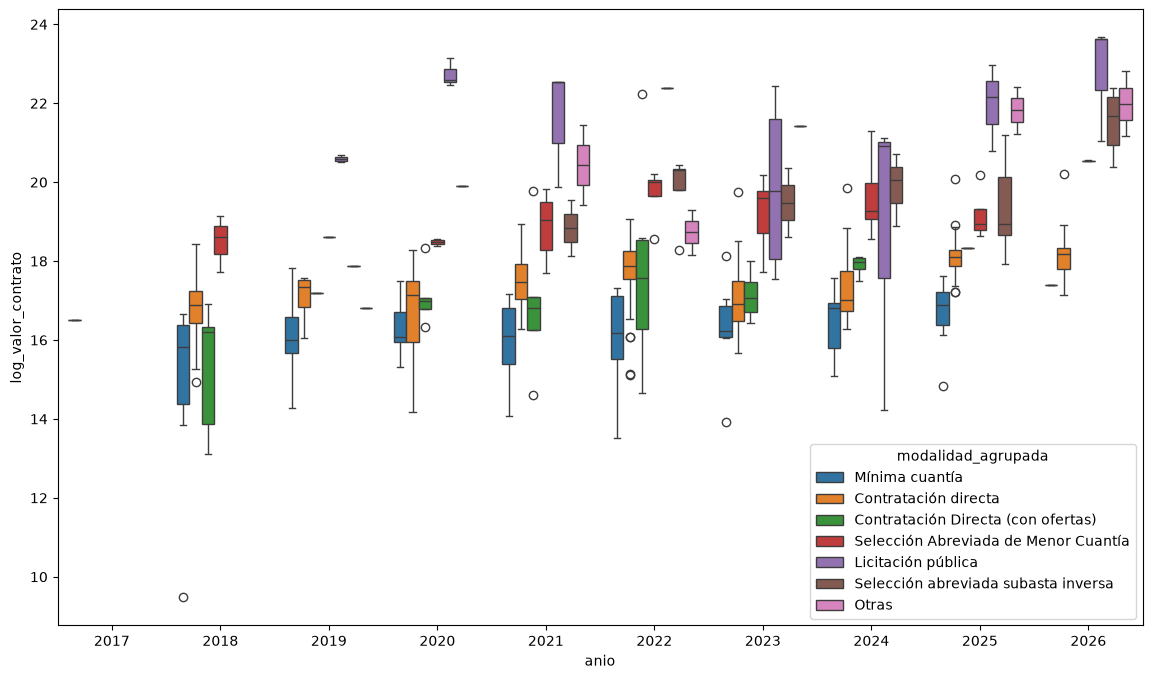

In [ ]:
plt.figure(figsize=(14,8))
sns.boxplot(data=dff_final, x='anio', y='log_valor_contrato', hue='modalidad_agrupada')
plt.show()

Año contra el valor del contrato, coloreando por modalidad

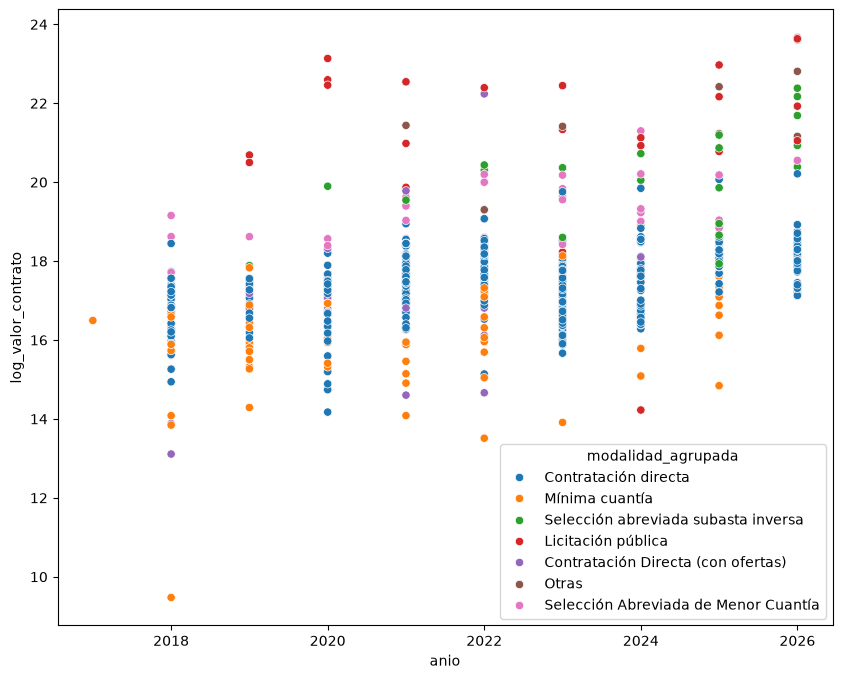

In [228]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=dff_final, x='anio', y='log_valor_contrato', hue='modalidad_agrupada')
plt.show()


Calculamos la matriz de correlación entre año y valor del contrato

In [230]:
corr_matrix = dff_final[['anio', 'log_valor_contrato']].corr()
corr_matrix


,anio,log_valor_contrato
anio,1.000000,0.373202
log_valor_contrato,0.373202,1.000000


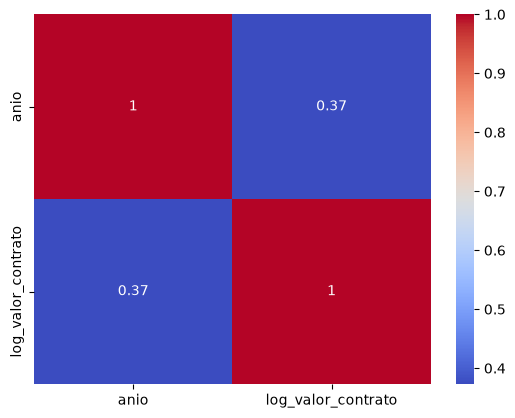

In [231]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


## Pruebas estadísticas

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# modalidad * año 
modelo_interaccion = smf.ols('log_valor_contrato ~ modalidad_agrupada * anio', data=dff_final).fit()
print(modelo_interaccion.summary())

                            OLS Regression Results                            
Dep. Variable:     log_valor_contrato   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     89.41
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          8.71e-142
Time:                        10:49:36   Log-Likelihood:                -1025.0
No. Observations:                 752   AIC:                             2078.
Df Residuals:                     738   BIC:                             2143.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [248]:
sm.stats.anova_lm(modelo_interaccion, typ=2)

,sum_sq,df,F,PR(>F)
modalidad_agrupada,797.132293,6.0,145.798330,1.056236e-121
anio,103.257448,1.0,113.316926,1.025748e-24
modalidad_agrupada:anio,20.786205,6.0,3.801871,9.716279e-04
Residual,672.485562,738.0,NaN,NaN


In [ ]:
# Centramos el año para que el intercepto sea interpretable 
dff_final['anio_centrado'] = dff_final['anio'] - dff_final['anio'].mean()

# Ajustamos con errores estándar robustos a heterocedasticidad (HC3)
modelo_interaccion = smf.ols(
    'log_valor_contrato ~ modalidad_agrupada * anio_centrado', data=dff_final
).fit(cov_type='HC3')
print(modelo_interaccion.summary())

                            OLS Regression Results                            
Dep. Variable:     log_valor_contrato   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     55.86
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          1.65e-100
Time:                        11:59:46   Log-Likelihood:                -1025.0
No. Observations:                 752   AIC:                             2078.
Df Residuals:                     738   BIC:                             2143.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

In [262]:
# ANOVA tipo II sobre el modelo con interacción.
anova_tabla = sm.stats.anova_lm(modelo_interaccion, typ=2)
anova_tabla

,sum_sq,df,F,PR(>F)
modalidad_agrupada,473.133313,6.0,86.537765,5.023006e-82
anio_centrado,161.985561,1.0,177.766410,1.720159e-36
modalidad_agrupada:anio_centrado,10.206971,6.0,1.866891,8.393061e-02
Residual,672.485562,738.0,NaN,NaN


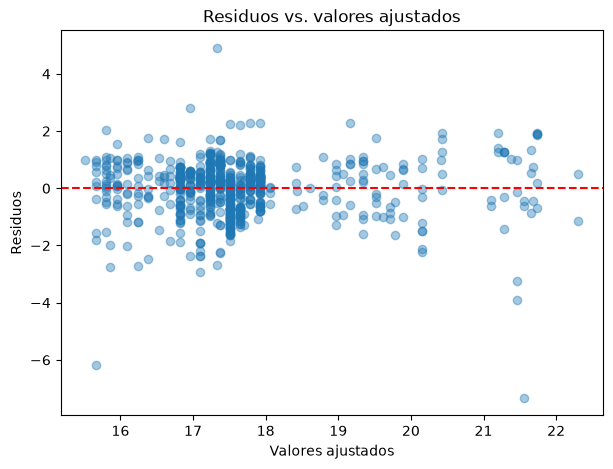

In [ ]:
# Residuos vs valores ajustados(linealidad/homocedasticidad)
fitted = modelo_interaccion.fittedvalues
residuos = modelo_interaccion.resid

plt.figure(figsize=(7,5))
plt.scatter(fitted, residuos, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs. valores ajustados')
plt.show()

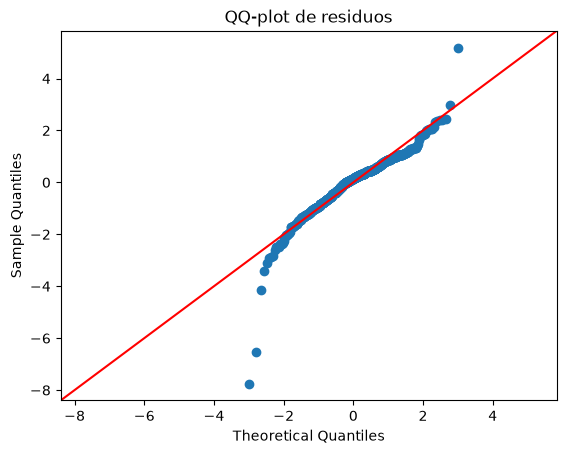

Breusch-Pagan: stat=63.238, p-valor=1.375e-08
-> Se confirma heterocedasticidad: los errores robustos (HC3) del modelo son necesarios.


In [ ]:
# QQ-plot para evaluar normalidad de los residuos
sm.qqplot(residuos, line='45', fit=True)
plt.title('QQ-plot de residuos')
plt.show()

# Prueba de Breusch-Pagan (heterocedasticidad)
bp_stat, bp_p, _, _ = sm.stats.diagnostic.het_breuschpagan(residuos, modelo_interaccion.model.exog)
print(f"Breusch-Pagan: stat={bp_stat:.3f}, p-valor={bp_p:.4g}")